# Credit-Card Fraud Detection — Critical Reproduction Study

Name : Yarden Greenhut, ID : 327851895

**Course:** Data Science in Cyber — Final Project

**Source:** `anshpandey96/Credit-Card-Fraud-Detection`

**Its headline claims:** *Best model = Logistic Regression, **Accuracy ~99.8%, Recall (Fraud) 100%, Precision ~94%.***

**Dataset:** Kaggle ULB *creditcardfraud* (284,807 transactions, 492 frauds = 0.172%).

This notebook:
1. **Reproduces the author's own pipeline** and shows the advertised
   "Logistic Regression: 100% recall & 94% precision" does not hold on the real test set.
2. **Exposes the accuracy fallacy** behind the "~99.8% accuracy" headline (a trivial model scores ~99.83%).
3. **Re-evaluates with domain-appropriate metrics** — PR-AUC, MCC, F2.

Structure:
1. Data Loading  
2. EDA
3. Faithful Reproduction
4. Improved Pipeline
5. Leakage Counterfactual
6. Threshold Tuning
7. Error Analysis
8. Results.

## 0. Setup & configuration

In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve, classification_report,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from google.colab import files

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
def evaluate(y_true, y_pred, y_score=None, label=""):
    # Return metrics for one model as a dict.
    row = {
        "model": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),  #beta = 2 gives f2
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    if y_score is not None:
        row["roc_auc"] = roc_auc_score(y_true, y_score) #ROC-AUC
        row["pr_auc"] = average_precision_score(y_true, y_score) #PR-AUC
    return row

* **Accuracy:** Measures the overall percentage of correctly classified transactions, but it is not reliable for highly imbalanced datasets like the one we are using.

* **Precision:** Measures the proportion of transactions predicted as fraud that are actually fraud.

* **Recall:** Measures the proportion of actual fraud transactions that are correctly detected by the model.

* **F1 Score:** Combines precision and recall into a single metric by calculating their harmonic mean.

* **F2 Score:** Similar to the F1 score but places greater emphasis on recall, making it more suitable for fraud detection, because missing fraud is more costly that preducting a non fraud as a fruad.

* **MCC:** Provides a balanced evaluation of classification performance by considering true and false positives and negatives, even for imbalanced datasets.

* **ROC-AUC:** Measures the model's ability to distinguish between fraud and legitimate transactions across all classification thresholds.

* **PR-AUC:** Measures the trade-off between precision and recall across different thresholds and is particularly useful for evaluating fraud detection on imbalanced datasets.


## 1. Data Loading

Coverage: loading, inspection, size and feature types, missing values, column/index sanity, duplicates.

In [6]:
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [7]:
DATA_PATH = Path("creditcard.csv")
assert DATA_PATH.exists(), (
    "creditcard.csv not found. Download from "
    "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud and place it here."
)

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


In [9]:
# Missing values, verify and state it explicitly.
missing = df.isna().sum()
print("Total missing values:", int(missing.sum()))
print(missing[missing > 0] if missing.sum() else "No missing values in any column.")

Total missing values: 0
No missing values in any column.


In [10]:
# Duplicate rows
n_dup = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dup:,} ({n_dup / len(df):.4%})")
df = df.drop_duplicates().reset_index(drop=True)   # the author does this too (a strength)
print(f"Shape after dropping duplicates: {df.shape}")

Exact duplicate rows: 1,081 (0.3796%)
Shape after dropping duplicates: (283726, 31)


In [26]:
# Column and index sanity: expect Time, V1..V28 (PCA), Amount, Class.

"""
NOTE: V1..V28 are anonymized PCA components, they are already de-correlated and standardized.
This limits domain feature engineering and interpretability (discuss in report).
"""

print("Dataset columns:")
for col in df.columns:
    print(f" - {col}")

print("\nClass values:")
print(sorted(df["Class"].unique()))
print("0 = Legitimate transaction, 1 = Fraudulent transaction")

Dataset columns:
 - Time
 - V1
 - V2
 - V3
 - V4
 - V5
 - V6
 - V7
 - V8
 - V9
 - V10
 - V11
 - V12
 - V13
 - V14
 - V15
 - V16
 - V17
 - V18
 - V19
 - V20
 - V21
 - V22
 - V23
 - V24
 - V25
 - V26
 - V27
 - V28
 - Amount
 - Class
 - hour_of_day

Class values:
[np.int64(0), np.int64(1)]
0 = Legitimate transaction, 1 = Fraudulent transaction


### Temporal analysis

`Time` = seconds since the first transaction (~2 days total). We derive hour of day to test whether
fraud concentrates at particular times.

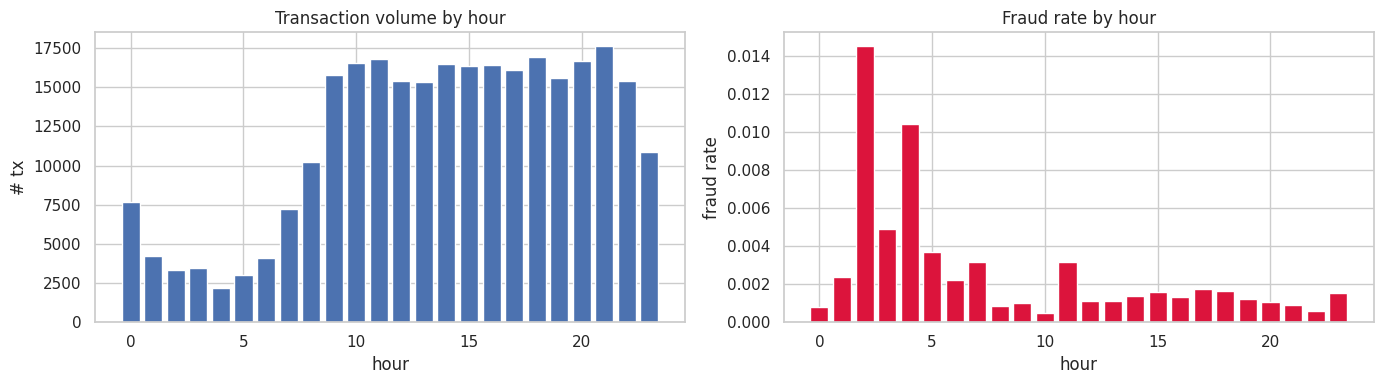

,fraud_rate,n_fraud,n_tx
hour_of_day,,,
0,0.0008,6,7647
1,0.0024,10,4208
2,0.0145,48,3308
3,0.0049,17,3487
4,0.0104,23,2204
5,0.0037,11,2988
6,0.0022,9,4082
7,0.0032,23,7233
8,0.0009,9,10232


In [18]:
df["hour_of_day"] = (df["Time"] // 3600 % 24).astype(int)
hourly = df.groupby("hour_of_day")["Class"].agg(fraud_rate="mean", n_fraud="sum", n_tx="count")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(hourly.index, hourly["n_tx"]); ax[0].set(title="Transaction volume by hour", xlabel="hour", ylabel="# tx")
ax[1].bar(hourly.index, hourly["fraud_rate"], color="crimson"); ax[1].set(title="Fraud rate by hour", xlabel="hour", ylabel="fraud rate")
plt.tight_layout(); plt.show()
print("\n")
hourly

## 2. Exploratory Data Analysis

###2.1 Class imbalance and accuracy


Fraud prevalence: 0.1667%  (1 fraud per ~599 transactions)


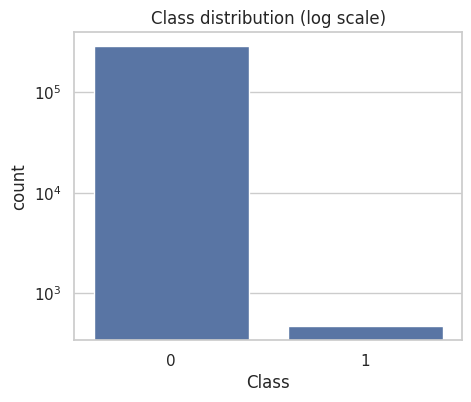

In [22]:
counts = df["Class"].value_counts()
prevalence = df["Class"].mean()
print(f"\nFraud prevalence: {prevalence:.4%}  (1 fraud per ~{int(1/prevalence):,} transactions)")

plt.figure(figsize=(5, 4))
sns.countplot(x="Class", data=df); plt.yscale("log")
plt.title("Class distribution (log scale)"); plt.show()
# Meaning: frauds are rare anomalies which means accuracy is misleading (predicting 'always legit' give high accuracy).

###2.2 Amount (money spent): heavy right skew motivates a log transform


Amount skewness: 16.98


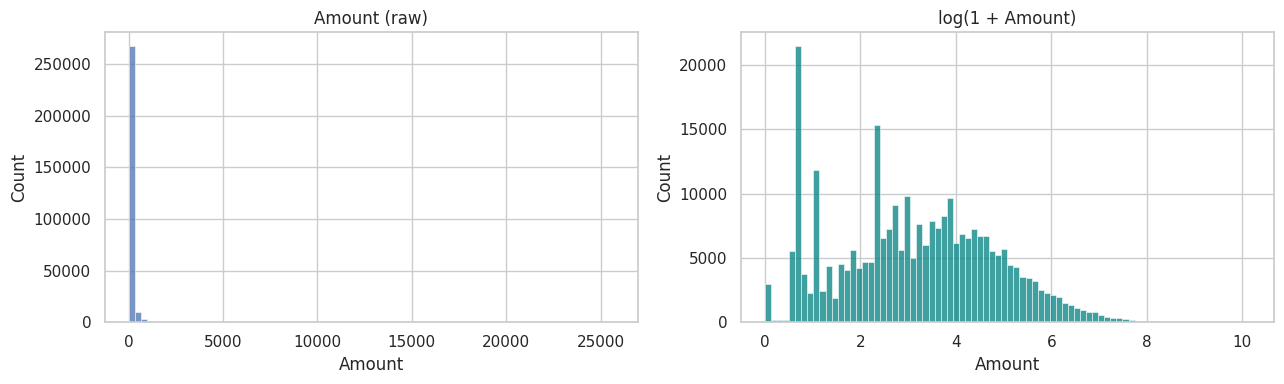

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,"283,253.0000",88.4136,250.3790,0.0000,5.6700,22.0000,77.4600,"25,691.1600"
1,473.0000,123.8719,260.2110,0.0000,1.0000,9.8200,105.8900,"2,125.8700"


In [27]:
"""
The Amount - Count histogram: Money spent vs How many transactions had an amount in that range.

Explenation of the table below:
Cont - number of transactions made in that class.
means - the average amount spent in that class.
std - the standard deviation of the amount spent in that class.
min - the minimum amount spent in that class.
25% - 25 precentage are below that amount
50% - the median.
75% - 75 precentage are below that amount
max - the maximum amount spent in that class.
"""

print("Amount skewness:", round(df['Amount'].skew(), 2))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["Amount"], bins=80, ax=ax[0]); ax[0].set(title="Amount (raw)")
sns.histplot(np.log1p(df["Amount"]), bins=80, ax=ax[1], color="teal"); ax[1].set(title="log(1 + Amount)")
plt.tight_layout(); plt.show()
print()
df.groupby("Class")["Amount"].describe()

###2.3 Correlation: Spearman
**Goal**: Identify which features are most strongly associated with fraud (Class).

- Pearson correlation measures the strength of a linear relationship between two variables. It is sensitive to outliers and works best when the relationship is approximately linear.

- Spearman correlation measures the strength of a monotonic relationship by comparing the ranks of the values rather than the values themselves. Because it is rank-based, it is more robust to outliers and non-normal data.

Why Spearman instead of Pearson?

  (a) The Amount feature is highly skewed and contains outliers, making Pearson correlation less reliable.

  (b) Spearman can detect monotonic relationships, not just linear ones.

  (c) Since Spearman is based on ranks, it is less affected by extreme values.

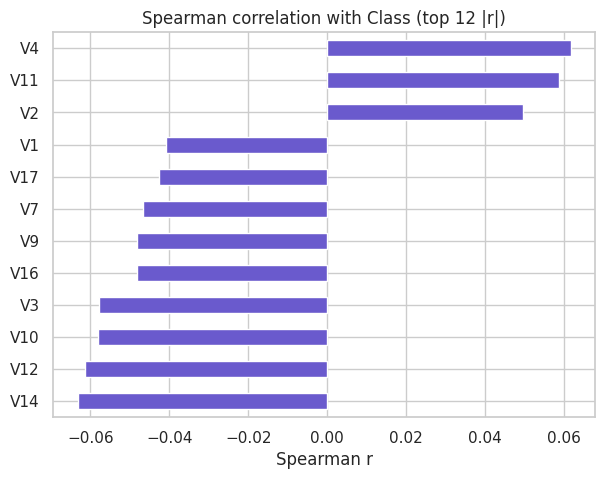

,Class
V14,0.0632
V4,0.0617
V12,0.0614
V11,0.0586
V10,0.0580
V3,0.0577
V2,0.0494
V16,0.0483
V9,0.0482
V7,0.0466


In [29]:
feature_cols = [c for c in df.columns if c != "Class"]
spearman_corr = df[feature_cols + ["Class"]].corr(method="spearman")["Class"].drop("Class")
top = spearman_corr.abs().sort_values(ascending=False).head(12)

plt.figure(figsize=(7, 5))
spearman_corr.loc[top.index].sort_values().plot(kind="barh", color="slateblue")
plt.title("Spearman correlation with Class (top 12 |r|)"); plt.xlabel("Spearman r"); plt.show()
top

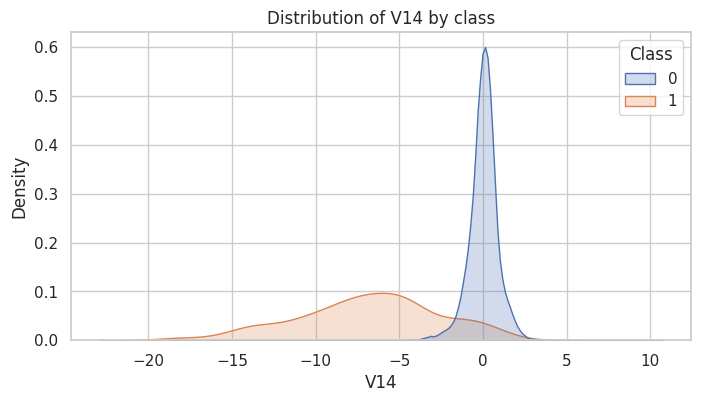

Strongest single correlate with Class: V14


In [30]:
# Distribution of the strongest correlate feature, split by class
strongest = spearman_corr.abs().idxmax()
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x=strongest, hue="Class", common_norm=False, fill=True)
plt.title(f"Distribution of {strongest} by class"); plt.show()
print("Strongest single correlate with Class:", strongest)

## 3. Reproduction of the Author's Pipeline

We followed the same steps as the original project to fairly test its claims using the real dataset.

First, we cleaned the data and split it into 80% training and 20% testing, while keeping the same ratio of fraud and non-fraud cases.

Next, we standardized the features using only the training data to avoid data leakage.

We then applied SMOTE only to the training set to balance the classes by creating synthetic fraud examples.

Finally, we trained two models Logistic Regression, Random Forest and compared their performance.

The project chooses the best model based on the F1-score, so we did the same and then checked whether our results matched the README's claim that Logistic Regression achieves 100% recall and 94% precision.


In [45]:
def reproduce_author_pipeline(data):
    data = data.drop(columns=["hour_of_day"], errors="ignore").drop_duplicates().reset_index(drop=True)

    X = data.drop(columns=["Class"])
    y = data["Class"].astype(int)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # Fit scaler only on training data
    scale_cols = ["Time", "Amount"]

    scaler = StandardScaler().fit(X_tr[scale_cols])

    X_tr = X_tr.copy()
    X_te = X_te.copy()

    X_tr[scale_cols] = scaler.transform(X_tr[scale_cols])
    X_te[scale_cols] = scaler.transform(X_te[scale_cols])

    k = min(5, int(y_tr.value_counts().min()) - 1)
    X_tr_b, y_tr_b = SMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=k
    ).fit_resample(X_tr, y_tr)

    authors_models = {
        "LogReg (author repro)": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "RandomForest (author repro)": RandomForestClassifier(
            n_estimators=120,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=1
        ),
    }

    rows = []

    for name, model in authors_models.items():
        model.fit(X_tr_b, y_tr_b)
        pred = model.predict(X_te)
        score = model.predict_proba(X_te)[:, 1]
        rows.append(evaluate(y_te, pred, score, name))

    return pd.DataFrame(rows).set_index("model"), (y_te, authors_models)


repro_df, _ = reproduce_author_pipeline(df)
repro_df[["accuracy", "precision", "recall", "f1", "f2", "mcc", "roc_auc", "pr_auc"]]

,accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
model,,,,,,,,
LogReg (author repro),0.9736,0.0529,0.8737,0.0998,0.2130,0.2114,0.9590,0.6828
RandomForest (author repro),0.9995,0.9221,0.7474,0.8256,0.7768,0.8299,0.9640,0.8036


In [46]:
# Author's CLAIM vs OBSERVED (critical evaluation)
claimed = {"accuracy": 0.998, "recall": 1.00, "precision": 0.94}
lr = repro_df.loc["LogReg (author repro)"]
comparison = pd.DataFrame({
    "Claimed (README)": [claimed["accuracy"], claimed["recall"], claimed["precision"]],
    "Observed (repro)": [lr["accuracy"], lr["recall"], lr["precision"]],
}, index=["accuracy", "recall", "precision"])
comparison["gap"] = comparison["Observed (repro)"] - comparison["Claimed (README)"]
print("Logistic Regression — author's claim vs our faithful reproduction:")
comparison

Logistic Regression — author's claim vs our faithful reproduction:


,Claimed (README),Observed (repro),gap
accuracy,0.9980,0.9736,-0.0244
recall,1.0000,0.8737,-0.1263
precision,0.9400,0.0529,-0.8871


**Results:**

1. Accuracy is similar to the reported value, but it is not a meaningful metric for this highly imbalanced dataset. The claimed 94% precision for Logistic Regression is not reproduced in our evaluation.

2. Logistic Regression with SMOTE detects more fraud cases, but it also incorrectly labels some normal transactions as fraud.

## 4. Improved Pipeline, Feature Engineering and Model Comparison

We create our own improved machine learning pipeline by adding new useful features and testing several different models.

All models are evaluated on the original test set, which keeps the real fraud/non-fraud ratio. This gives a more realistic measure of performance.

We compare:
- DummyClassifier: a simple baseline model that shows why accuracy can be misleading in an imbalanced dataset.
- Logistic Regression and Random Forest: models that handle class imbalance by giving more importance to fraud cases.
- XGBoost: a powerful model that adjusts for the small number of fraud cases using class weights.
- Isolation Forest: an unsupervised model that tries to detect unusual transactions without using fraud labels.

The goal is to find which model can detect fraud effectively while keeping false alarms low.

###4.1 Feature engineering

We created additional features by applying a log transformation to transaction amounts to reduce the effect of extreme values and by using the transaction time information.

The dataset was split into training and testing sets while preserving the fraud ratio.

Only non-PCA features were standardized because the PCA components were already normalized.

The scaler was fitted only on the training data to prevent data leakage.

In [33]:
# Feature engineering: log-amount + hour_of_day.
df["log_Amount"] = np.log1p(df["Amount"])
FEATURES = [c for c in df.columns if c != "Class"]
X, y = df[FEATURES].copy(), df["Class"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Scale only the raw-scale / engineered cols. V1..V28 already standardized by PCA. Fit on train.
scale_cols = ["Time", "Amount", "log_Amount", "hour_of_day"]
scaler = StandardScaler().fit(X_train[scale_cols])
X_train[scale_cols] = scaler.transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])
print(f"Train {X_train.shape} (fraud={y_train.sum()}) | Test {X_test.shape} (fraud={y_test.sum()})")

Train (198608, 32) (fraud=331) | Test (85118, 32) (fraud=142)


###4.2 The models

In [35]:
results = []

# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
results.append(
    evaluate(y_test, dummy_pred, np.zeros(len(y_test)), "Dummy (always legit)")
)

print(f"Dummy accuracy = {results[-1]['accuracy']:.4%}")
print("Note: This model predicts all transactions as legitimate, so it catches 0 fraud cases.")

# Logistic Regression
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
).fit(X_train, y_train)

lr_score = logreg.predict_proba(X_test)[:, 1]
results.append(
    evaluate(y_test, logreg.predict(X_test), lr_score, "Logistic Regression")
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
).fit(X_train, y_train)

rf_score = rf.predict_proba(X_test)[:, 1]
results.append(
    evaluate(y_test, rf.predict(X_test), rf_score, "Random Forest")
)

# XGBoost
spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    scale_pos_weight=spw,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

xgb_score = xgb.predict_proba(X_test)[:, 1]
results.append(
    evaluate(y_test, xgb.predict(X_test), xgb_score, "XGBoost")
)

# Isolation Forest - unsupervised anomaly detection
iso = IsolationForest(
    n_estimators=200,
    contamination=float(y_train.mean()),
    random_state=RANDOM_STATE,
    n_jobs=-1
).fit(X_train)

iso_score = -iso.score_samples(X_test)  # higher score = more anomalous
iso_pred = (iso.predict(X_test) == -1).astype(int)  # -1 = anomaly = fraud

results.append(
    evaluate(y_test, iso_pred, iso_score, "Isolation Forest (unsupervised)")
)

Dummy accuracy = 99.8332%
Note: This model predicts all transactions as legitimate, so it catches 0 fraud cases.


In [36]:
"""
To avoid data leakage, SMOTE was applied only to the training data using an imbalanced-learn pipeline.
This ensures that synthetic fraud examples are created only during model training and that the test data remains untouched.

The models were evaluated using stratified cross-validation,
which preserves the fraud/non-fraud ratio in each fold and provides a more reliable performance estimate.
"""

smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)), # runs per training fold only
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_score = cross_val_predict(smote_pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
results.append(evaluate(y_train, (cv_score >= 0.5).astype(int), cv_score, "LogReg + SMOTE-in-CV (honest)"))

###4.3 Results

In [37]:
# Consolidated comparison: author reproduction + our improved models
metrics_df = pd.concat([repro_df, pd.DataFrame(results).set_index("model")])
metrics_df = metrics_df[["accuracy", "precision", "recall", "f1", "f2", "mcc", "roc_auc", "pr_auc"]]
metrics_df.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["pr_auc", "mcc", "f2"])

,accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
model,,,,,,,,
LogReg (author repro),0.9737,0.0530,0.8737,0.1000,0.2134,0.2116,0.9626,0.6750
RandomForest (author repro),0.9995,0.9114,0.7579,0.8276,0.7843,0.8309,0.9704,0.8133
Dummy (always legit),0.9983,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0017
Logistic Regression,0.9729,0.0521,0.8873,0.0984,0.2108,0.2113,0.9676,0.6982
Random Forest,0.9995,0.9528,0.7113,0.8145,0.7493,0.8230,0.9413,0.8232
XGBoost,0.9995,0.8810,0.7817,0.8284,0.7997,0.8296,0.9717,0.8244
Isolation Forest (unsupervised),0.9972,0.1655,0.1620,0.1637,0.1627,0.1623,0.9380,0.0873
LogReg + SMOTE-in-CV (honest),0.9721,0.0519,0.9094,0.0981,0.2111,0.2135,0.9789,0.7412


## 5. What SMOTE-before-split Leakage Would Have Done

The author avoided the common mistake of resampling before splitting (a genuine strength).

To show
why that matters, we deliberately commit the error here - SMOTE on the full data, then split - and
measure the inflation.

This contextualizes the critique: the README's optimistic numbers are not
explained by leakage, they may be simply an over-optimistic reading of a single run.

In [38]:
X_raw = df[[c for c in df.columns if c not in {"Class", "log_Amount"}]]
X_leak, y_leak = SMOTE(random_state=RANDOM_STATE).fit_resample(X_raw, df["Class"])
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_leak, y_leak, test_size=0.30, stratify=y_leak, random_state=RANDOM_STATE
)
leaky = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xl_tr, yl_tr)
leaky_row = evaluate(yl_te, leaky.predict(Xl_te), leaky.predict_proba(Xl_te)[:, 1],
                     "LogReg (LEAKY SMOTE-before-split)")
pd.DataFrame([leaky_row, repro_df.loc["LogReg (author repro)"].to_dict() | {"model": "LogReg (correct order)"}]
             ).set_index("model")[["precision", "recall", "f1", "mcc", "pr_auc"]]
# The leaky row's precision/recall are artificially high -> a caution, not the author's actual result.

,precision,recall,f1,mcc,pr_auc
model,,,,,
LogReg (LEAKY SMOTE-before-split),0.9884,0.9645,0.9763,0.9534,0.9969
LogReg (correct order),0.0530,0.8737,0.1000,0.2116,0.6750


## 6. Evaluation and Threshold Tuning

The default classification threshold of 0.5 was not assumed to be optimal because fraud detection requires balancing missed fraud against false alarms.

We selected the best supervised model using PR-AUC, then adjusted its decision threshold using the precision-recall curve.

The chosen threshold was selected to achieve at least 85% recall while maximizing precision.

This approach reflects a realistic fraud detection scenario where detecting most fraud cases is more important than maximizing overall accuracy.

Best supervised model by PR-AUC: XGBoost


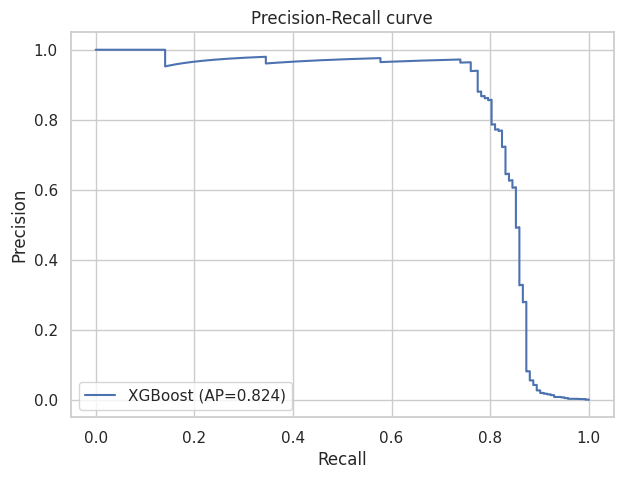

In [39]:
# Finding the best model

candidates = {"Logistic Regression": lr_score, "Random Forest": rf_score, "XGBoost": xgb_score}
best_name = max(candidates, key=lambda n: average_precision_score(y_test, candidates[n]))
best_score = candidates[best_name]
print(f"Best supervised model by PR-AUC: {best_name}")

prec, rec, thr = precision_recall_curve(y_test, best_score)
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label=f"{best_name} (AP={average_precision_score(y_test, best_score):.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curve")
plt.legend()
plt.show()

Chosen threshold = 0.0665



,precision,recall,f1-score,support
0,0.9998,0.9991,0.9994,"84,976.0000"
1,0.6080,0.8521,0.7097,142.0000
accuracy,0.9988,0.9988,0.9988,0.9988
macro avg,0.8039,0.9256,0.8545,"85,118.0000"
weighted avg,0.9991,0.9988,0.9989,"85,118.0000"


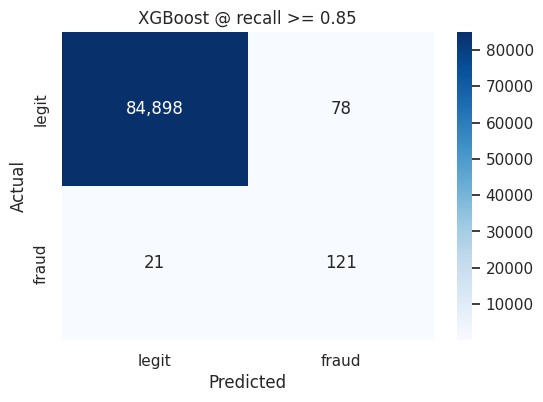

In [41]:
# Choose a threshold that achieves the target recall while maximizing precision
TARGET_RECALL = 0.85

# Keep only thresholds where recall is at least the target
mask = rec[:-1] >= TARGET_RECALL

# Among those thresholds, select the one with the highest precision
chosen_thr = thr[mask][np.argmax(prec[:-1][mask])]

# Apply the chosen threshold instead of the default 0.5
tuned_pred = (best_score >= chosen_thr).astype(int)

# Print chosen threshold
print(f"Chosen threshold = {chosen_thr:.4f}\n")

# Classification report as a clean table
report = pd.DataFrame(
    classification_report(
        y_test,
        tuned_pred,
        digits=4,
        output_dict=True
    )
).transpose()

display(report.round(4))

# Confusion matrix
cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["legit", "fraud"],
    yticklabels=["legit", "fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{best_name} @ recall >= {TARGET_RECALL}")
plt.show()

## 7. Error Analysis

We perform additional error analysis by examining false negatives and false positives on the test set.

False negatives represent fraud transactions that the model failed to detect, while false positives represent legitimate transactions incorrectly flagged as fraud.

We also compare transaction amounts between missed and detected fraud cases and inspected the highest-scoring missed fraud examples to understand where the model struggles.

In [42]:
test_df = X_test.copy()
test_df["actual"], test_df["pred"], test_df["fraud_score"] = y_test.values, tuned_pred, best_score
false_neg = test_df[(test_df.actual == 1) & (test_df.pred == 0)]
false_pos = test_df[(test_df.actual == 0) & (test_df.pred == 1)]
print(f"False Negatives (missed frauds): {len(false_neg)} | False Positives (false alarms): {len(false_pos)}")

print("\nAmount (standardized) median — missed vs caught frauds:")
print("  missed (FN):", round(false_neg['Amount'].median(), 3),
      "| caught (TP):", round(test_df[(test_df.actual==1)&(test_df.pred==1)]['Amount'].median(), 3))
false_neg.sort_values("fraud_score", ascending=False).head()

False Negatives (missed frauds): 21 | False Positives (false alarms): 78

Amount (standardized) median — missed vs caught frauds:
  missed (FN): -0.359 | caught (TP): -0.286


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,hour_of_day,log_Amount,actual,pred,fraud_score
10162,-1.6658,-4.6419,2.9021,-1.5729,2.5073,-0.8718,-1.0409,-1.5939,-3.2549,1.9090,...,-0.3546,-0.6118,-3.9081,-0.6712,-0.3171,-1.7243,-0.3860,1,0,0.0427
68058,-0.8841,1.0366,0.4072,0.7577,3.1618,-0.5681,0.2022,-0.6898,0.4114,0.3368,...,0.5077,0.1896,0.0610,0.0631,-0.3609,-0.0088,-1.5644,1,0,0.0188
231118,1.0968,-2.0642,2.6297,-0.7484,0.6950,0.4182,1.3925,-1.6978,-6.3331,1.7242,...,0.2092,-0.3199,0.0154,-0.0501,-0.3311,0.3343,-0.5790,1,0,0.0142
29566,-1.2495,-2.0190,1.4913,0.0052,0.8173,0.9733,-0.6393,-0.9741,-3.1469,-0.0032,...,-0.3291,0.5236,0.6263,0.1524,-0.3609,-0.8666,-1.5644,1,0,0.0024
239334,1.1704,1.8529,1.0696,-1.7761,4.6174,0.7704,-0.4009,-0.0410,0.0895,-0.2177,...,0.0581,0.1483,0.0423,0.0406,-0.3599,0.5059,-1.4872,1,0,0.0014


We analyzed how changing the decision threshold affects false positives and false negatives.

A lower threshold allows the model to detect more fraud cases but increases false alarms.

A higher threshold reduces false alarms but risks missing more fraud.

The selected threshold represents a balance between catching fraud and limiting unnecessary alerts.

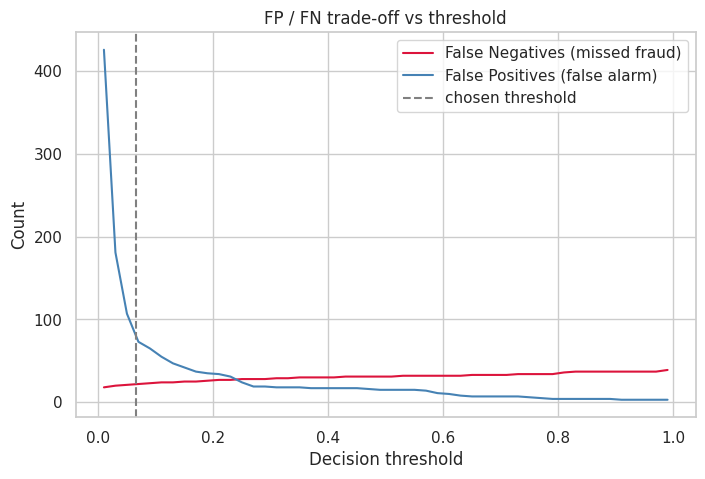

In [43]:
grid = np.linspace(0.01, 0.99, 50)
fn_counts = [((best_score < t) & (y_test.values == 1)).sum() for t in grid]
fp_counts = [((best_score >= t) & (y_test.values == 0)).sum() for t in grid]
plt.figure(figsize=(8, 5))
plt.plot(grid, fn_counts, label="False Negatives (missed fraud)", color="crimson")
plt.plot(grid, fp_counts, label="False Positives (false alarm)", color="steelblue")
plt.axvline(chosen_thr, ls="--", color="gray", label="chosen threshold")
plt.xlabel("Decision threshold"); plt.ylabel("Count"); plt.legend()
plt.title("FP / FN trade-off vs threshold"); plt.show()

## 8. Results Summary

- **Dummy** around 99.83% accuracy confirms accuracy is the wrong headline metric.
- **Faithful reproduction** shows the author's "100% recall / 94% precision" for Logistic Regression is
  not reproduced. The precision claim in particular collapses.
- On **PR-AUC / MCC / F2**, tree ensembles (Random Forest / XGBoost) clearly beat Logistic Regression.
- The author's code is sound (correct split/SMOTE order, F1 selection). The claims and metrics are not.

See the PDF report for full metric definitions, the critical evaluation, and conclusions.

In [44]:
print("Final comparison (sorted by PR-AUC):")
metrics_df.sort_values("pr_auc", ascending=False).style.format("{:.4f}")

Final comparison (sorted by PR-AUC):


,accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
model,,,,,,,,
XGBoost,0.9995,0.8810,0.7817,0.8284,0.7997,0.8296,0.9717,0.8244
Random Forest,0.9995,0.9528,0.7113,0.8145,0.7493,0.8230,0.9413,0.8232
RandomForest (author repro),0.9995,0.9114,0.7579,0.8276,0.7843,0.8309,0.9704,0.8133
LogReg + SMOTE-in-CV (honest),0.9721,0.0519,0.9094,0.0981,0.2111,0.2135,0.9789,0.7412
Logistic Regression,0.9729,0.0521,0.8873,0.0984,0.2108,0.2113,0.9676,0.6982
LogReg (author repro),0.9737,0.0530,0.8737,0.1000,0.2134,0.2116,0.9626,0.6750
Isolation Forest (unsupervised),0.9972,0.1655,0.1620,0.1637,0.1627,0.1623,0.9380,0.0873
Dummy (always legit),0.9983,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0017
